# Large Gaussian Multislice Benchmark

This notebook tests whether a TEM input wave decomposed into more than 50,000 Gaussian beams can follow a 10-slice Au [001] multislice sample and reproduce the same output field as a Fresnel multislice reference.

`abtem` is not installed in this environment, so the sample is generated directly as an abTEM-style fcc Au [001] slab using ASE-compatible geometry and the Lobato Au coefficients already used in the atom-slice notebook. The Gaussian and Fresnel paths use the same projected slice potential, so the comparison isolates the Gaussian quadratic-fit approximation.

## Setup

Restart the kernel before changing the memory environment variables. For the full 50k-beam GPU run, close other GPU kernels first if possible. If the compiled Fresnel reference runs out of memory, set `TEMGYM_REFERENCE_JIT=0` before starting the kernel.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.85")

import jax
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
while repo_root.name != "TemGymCore" and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.atoms.multislice_gaussian_benchmark import (
    MultisliceBenchmarkConfig,
    quick_config,
    run_benchmark,
    save_outputs,
)

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.default_backend())


JAX backend: gpu


## Full 50k-Beam TEM Case

The default configuration uses a 9 x 9 Au [001] lateral supercell, 10 alternating fcc atomic planes, a 192 x 192 detector grid, and a 224 x 224 square Gaussian tiling of the TEM entrance wave. That gives 50,176 Gaussian beams.

For a fast sanity check, replace `config = MultisliceBenchmarkConfig(...)` with `config = quick_config()`. By default, `interaction_thickness=None` uses the propagation distance as the finite projected-potential thickness for each atom plane.

In [2]:
config = MultisliceBenchmarkConfig(
    n_cells_xy=9,
    n_slices=10,
    grid_shape=192,
    target_beams_side=224,  # 224 x 224 = 50,176 beams
    beam_chunk_size=1792,   # divides 50,176 exactly into 28 chunks
    fit_samples_per_axis=3,
    fit_support_radius=1.0,
    interaction_thickness=None,  # default: same as propagation_per_slice
    projection_samples=9,
    reference_jit=os.environ.get("TEMGYM_REFERENCE_JIT", "1") != "0",
    record_slices=True,
)

result = run_benchmark(config)


JAX backend: gpu
Grid: (192, 192), pixel=0.2537 A
Au [001] slices: 10, atoms/slice=162
TEM Gaussian beam count: 50176; waist=0.4348 A
Propagation per slice: 2.0390 A
Projected-potential thickness: 2.0390 A (9 z samples)
slice 01/10: fit=3.285s, propagate=0.869s, eval=0.085s
slice 02/10: fit=1.512s, propagate=0.616s, eval=0.082s
slice 03/10: fit=0.279s, propagate=0.299s, eval=0.077s
slice 04/10: fit=0.298s, propagate=0.293s, eval=0.076s
slice 05/10: fit=0.342s, propagate=0.313s, eval=0.082s
slice 06/10: fit=0.329s, propagate=0.329s, eval=0.081s
slice 07/10: fit=0.347s, propagate=0.328s, eval=0.080s
slice 08/10: fit=0.315s, propagate=0.292s, eval=0.079s
slice 09/10: fit=0.332s, propagate=0.310s, eval=0.075s
slice 10/10: fit=0.336s, propagate=0.329s, eval=0.082s
Field error: 0.227357
Intensity error: 0.0364288
Action-grid build total: 7.324s
Reference total: 0.348s
Gaussian path total: 11.438s


## Projected Atomic Potential By Slice

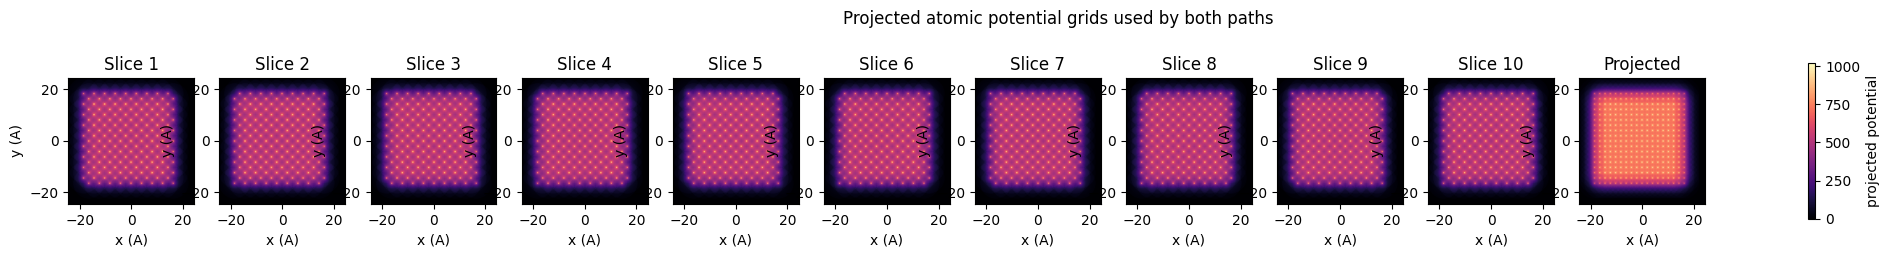

In [3]:
potential = np.asarray(result["potential_grid_stack"])
extent = float(result["extent"])
plot_extent = (-extent, extent, -extent, extent)
selected = np.linspace(0, potential.shape[0] - 1, min(potential.shape[0], 10), dtype=int)

fig, axes = plt.subplots(1, len(selected) + 1, figsize=(2.4 * (len(selected) + 1), 2.7))
axes = np.ravel(axes)
vmax = float(np.max(potential))
for ax, slice_index in zip(axes[:-1], selected):
    im = ax.imshow(
        potential[slice_index],
        extent=plot_extent,
        origin="lower",
        cmap="magma",
        vmin=0.0,
        vmax=vmax,
    )
    ax.set_title(f"Slice {slice_index + 1}")
    ax.set_xlabel("x (A)")
    ax.set_ylabel("y (A)")

im = axes[-1].imshow(np.sum(potential, axis=0), extent=plot_extent, origin="lower", cmap="magma")
axes[-1].set_title("Projected")
axes[-1].set_xlabel("x (A)")
axes[-1].set_ylabel("y (A)")
fig.colorbar(im, ax=axes.tolist(), shrink=0.75, label="projected potential")
fig.suptitle("Projected atomic potential grids used by both paths")
plt.show()


## Slice-By-Slice Field Evolution

In [4]:
reference_history = np.asarray(result["reference_history"])
gaussian_history = np.asarray(result["gaussian_history"])
ref_intensity = np.abs(reference_history) ** 2
gauss_intensity = np.abs(gaussian_history) ** 2
intensity_diff = gauss_intensity - ref_intensity
selected = np.linspace(0, reference_history.shape[0] - 1, min(reference_history.shape[0], 10), dtype=int)

fig, axes = plt.subplots(4, len(selected), figsize=(2.35 * len(selected), 8.2), sharex=True, sharey=True)
if len(selected) == 1:
    axes = axes[:, None]
intensity_vmax = float(max(np.max(ref_intensity), np.max(gauss_intensity)))
diff_vmax = float(np.max(np.abs(intensity_diff)))
for col, slice_index in enumerate(selected):
    panels = [
        (potential[slice_index], "Projected potential", "magma", 0.0, vmax),
        (ref_intensity[slice_index], "Fresnel |psi|^2", "inferno", 0.0, intensity_vmax),
        (gauss_intensity[slice_index], "Gaussian |psi|^2", "inferno", 0.0, intensity_vmax),
        (intensity_diff[slice_index], "Intensity diff", "coolwarm", -diff_vmax, diff_vmax),
    ]
    for row, (data, label, cmap, vmin, vmax_i) in enumerate(panels):
        axes[row, col].imshow(data, extent=plot_extent, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax_i)
        if row == 0:
            err = result["slice_intensity_errors"][slice_index]
            axes[row, col].set_title(f"Slice {slice_index + 1}
I err={err:.2e}")
        if col == 0:
            axes[row, col].set_ylabel(label)
        axes[row, col].set_xlabel("x (A)")
fig.suptitle("Projected potential and intensity evolution after each slice")
fig.tight_layout()
plt.show()


SyntaxError: unterminated f-string literal (detected at line 24) (3382048203.py, line 24)

## Slice-By-Slice Diffraction Evolution

In [ ]:
def diffraction_log_intensity(fields):
    diffraction = np.fft.fftshift(np.fft.fft2(fields, axes=(-2, -1)), axes=(-2, -1))
    intensity = np.abs(diffraction) ** 2
    scale = np.max(intensity, axis=(-2, -1), keepdims=True)
    return np.log10(intensity / np.maximum(scale, 1e-300) + 1e-12)

def diffraction_symmetric_limit(values, percentile=99.0):
    return max(float(np.percentile(np.abs(values), percentile)), 1e-12)

wavelength = float(result["input_beam"].to_vector().wavelength[0])
pixel = 2.0 * extent / reference_history.shape[-1]
freq = np.fft.fftshift(np.fft.fftfreq(reference_history.shape[-1], d=pixel))
angle_mrad = wavelength * freq * 1e3
angle_limit = min(float(np.max(np.abs(angle_mrad))), 30.0)
angle_mask = np.where(np.abs(angle_mrad) <= angle_limit)[0]
k0, k1 = int(angle_mask[0]), int(angle_mask[-1] + 1)
diffraction_extent = (angle_mrad[k0], angle_mrad[k1 - 1], angle_mrad[k0], angle_mrad[k1 - 1])

ref_diffraction = diffraction_log_intensity(reference_history)[:, k0:k1, k0:k1]
gauss_diffraction = diffraction_log_intensity(gaussian_history)[:, k0:k1, k0:k1]
diffraction_diff = gauss_diffraction - ref_diffraction
diffraction_diff_vmax = diffraction_symmetric_limit(diffraction_diff)

fig, axes = plt.subplots(3, len(selected), figsize=(2.35 * len(selected), 6.4), sharex=True, sharey=True)
if len(selected) == 1:
    axes = axes[:, None]
for col, slice_index in enumerate(selected):
    panels = [
        (ref_diffraction[slice_index], "Fresnel log diffraction", "inferno", -8.0, 0.0),
        (gauss_diffraction[slice_index], "Gaussian log diffraction", "inferno", -8.0, 0.0),
        (diffraction_diff[slice_index], "Log diffraction diff", "coolwarm", -diffraction_diff_vmax, diffraction_diff_vmax),
    ]
    for row, (data, label, cmap, vmin, vmax_i) in enumerate(panels):
        axes[row, col].imshow(data, extent=diffraction_extent, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax_i)
        if row == 0:
            axes[row, col].set_title(f"Slice {slice_index + 1}")
        if col == 0:
            axes[row, col].set_ylabel(label)
        axes[row, col].set_xlabel("angle x/y (mrad)")
fig.suptitle("Diffraction pattern evolution after each slice")
fig.tight_layout()
plt.show()


## Slice-By-Slice Phase Evolution

In [ ]:
relative_phase = np.angle(gaussian_history * np.conj(reference_history))
fig, axes = plt.subplots(3, len(selected), figsize=(2.35 * len(selected), 6.4), sharex=True, sharey=True)
if len(selected) == 1:
    axes = axes[:, None]
for col, slice_index in enumerate(selected):
    panels = [
        (np.angle(reference_history[slice_index]), "Fresnel phase", "twilight"),
        (np.angle(gaussian_history[slice_index]), "Gaussian phase", "twilight"),
        (relative_phase[slice_index], "Relative phase", "twilight"),
    ]
    for row, (data, label, cmap) in enumerate(panels):
        axes[row, col].imshow(data, extent=plot_extent, origin="lower", cmap=cmap)
        if row == 0:
            axes[row, col].set_title(f"Slice {slice_index + 1}")
        if col == 0:
            axes[row, col].set_ylabel(label)
        axes[row, col].set_xlabel("x (A)")
fig.suptitle("Phase evolution after each slice")
fig.tight_layout()
plt.show()


## Cropped Atom-Induced Modulation

In [ ]:
height, width = potential.shape[-2:]
x_coords = np.linspace(-extent, extent, width)
y_coords = np.linspace(-extent, extent, height)
crop_half_width = min(extent, 0.5 * config.n_cells_xy * config.lattice_constant + 1.0)
x_crop = np.where(np.abs(x_coords) <= crop_half_width)[0]
y_crop = np.where(np.abs(y_coords) <= crop_half_width)[0]
x0, x1 = int(x_crop[0]), int(x_crop[-1] + 1)
y0, y1 = int(y_crop[0]), int(y_crop[-1] + 1)
crop_extent = (x_coords[x0], x_coords[x1 - 1], y_coords[y0], y_coords[y1 - 1])

potential_crop = potential[:, y0:y1, x0:x1]
reference_crop = reference_history[:, y0:y1, x0:x1]
gaussian_crop = gaussian_history[:, y0:y1, x0:x1]
ref_i_crop = np.abs(reference_crop) ** 2
gauss_i_crop = np.abs(gaussian_crop) ** 2

def intensity_modulation(intensity):
    return intensity / np.mean(intensity, axis=(-2, -1), keepdims=True) - 1.0

def phase_modulation(fields):
    mean_phase = np.angle(np.mean(fields, axis=(-2, -1), keepdims=True))
    return np.angle(fields * np.exp(-1j * mean_phase))

def symmetric_limit(values, percentile=98.0):
    return max(float(np.percentile(np.abs(values), percentile)), 1e-12)

ref_i_mod = intensity_modulation(ref_i_crop)
gauss_i_mod = intensity_modulation(gauss_i_crop)
i_mod_diff = gauss_i_mod - ref_i_mod
ref_phase_mod = phase_modulation(reference_crop)
gauss_phase_mod = phase_modulation(gaussian_crop)
phase_mod_diff = np.angle(np.exp(1j * (gauss_phase_mod - ref_phase_mod)))

i_mod_vmax = symmetric_limit(np.concatenate((ref_i_mod.ravel(), gauss_i_mod.ravel())))
i_diff_vmax = symmetric_limit(i_mod_diff)
phase_vmax = symmetric_limit(np.concatenate((ref_phase_mod.ravel(), gauss_phase_mod.ravel())))
phase_diff_vmax = symmetric_limit(phase_mod_diff)
potential_vmax = float(np.max(potential_crop))

fig, axes = plt.subplots(7, len(selected), figsize=(2.35 * len(selected), 13.2), sharex=True, sharey=True)
if len(selected) == 1:
    axes = axes[:, None]
for col, slice_index in enumerate(selected):
    panels = [
        (potential_crop[slice_index], "Projected potential", "magma", 0.0, potential_vmax),
        (ref_i_mod[slice_index], "Fresnel I mod", "coolwarm", -i_mod_vmax, i_mod_vmax),
        (gauss_i_mod[slice_index], "Gaussian I mod", "coolwarm", -i_mod_vmax, i_mod_vmax),
        (i_mod_diff[slice_index], "I mod diff", "coolwarm", -i_diff_vmax, i_diff_vmax),
        (ref_phase_mod[slice_index], "Fresnel phase mod", "coolwarm", -phase_vmax, phase_vmax),
        (gauss_phase_mod[slice_index], "Gaussian phase mod", "coolwarm", -phase_vmax, phase_vmax),
        (phase_mod_diff[slice_index], "Phase mod diff", "coolwarm", -phase_diff_vmax, phase_diff_vmax),
    ]
    for row, (data, label, cmap, vmin, vmax_i) in enumerate(panels):
        axes[row, col].imshow(data, extent=crop_extent, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax_i)
        if row == 0:
            axes[row, col].set_title(f"Slice {slice_index + 1}")
        if col == 0:
            axes[row, col].set_ylabel(label)
        axes[row, col].set_xlabel("x (A)")
fig.suptitle("Cropped atom-induced intensity and phase modulation")
fig.tight_layout()
plt.show()


## Field Comparison

In [ ]:
reference = np.asarray(result["reference"])
gaussian = np.asarray(result["gaussian"])
diff = np.abs(gaussian) ** 2 - np.abs(reference) ** 2
extent = result["extent"]
plot_extent = (-extent, extent, -extent, extent)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)
images = [
    (np.abs(reference), "Fresnel amplitude", "inferno"),
    (np.abs(gaussian), "Gaussian amplitude", "inferno"),
    (diff, "Intensity difference", "coolwarm"),
    (np.angle(reference), "Fresnel phase", "twilight"),
    (np.angle(gaussian), "Gaussian phase", "twilight"),
    (np.angle(gaussian * np.conj(reference)), "Relative phase", "twilight"),
]
for ax, (data, title, cmap) in zip(axes.ravel(), images):
    im = ax.imshow(data, extent=plot_extent, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x (A)")
    ax.set_ylabel("y (A)")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle(
    f"field error={result['field_error']:.3g}, "
    f"intensity error={result['intensity_error']:.3g}"
)
fig.tight_layout()
plt.show()


## Timing Breakdown

In [ ]:
timings = result["timings"]
print(f"Input Gaussian eval   : {timings['input_eval']:.3f} s")
print(f"Action-grid build    : {timings['action_grid_total']:.3f} s")
print(f"Reference multislice : {timings['reference_total']:.3f} s")
print(f"Gaussian fit total    : {timings['gaussian_fit_total']:.3f} s")
print(f"Gaussian propagate    : {timings['gaussian_propagate_total']:.3f} s")
print(f"Output Gaussian eval  : {timings['output_eval']:.3f} s")
print(f"Gaussian path total   : {timings['gaussian_path_total']:.3f} s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(
    ["Reference", "Gaussian"],
    [timings["reference_total"], timings["gaussian_path_total"]],
    color=["#4C78A8", "#F58518"],
)
axes[0].set_ylabel("seconds")
axes[0].set_title("End-to-end path timing")

x = np.arange(config.n_slices) + 1
axes[1].plot(x, timings["action_grid_per_slice"], marker="o", label="Build action grid")
axes[1].plot(x, timings["reference_per_slice"], marker="o", label="Fresnel slice")
axes[1].plot(x, timings["gaussian_fit_per_slice"], marker="o", label="Gaussian fit")
axes[1].plot(x, timings["gaussian_propagate_per_slice"], marker="o", label="Gaussian propagate")
axes[1].set_xlabel("slice")
axes[1].set_ylabel("seconds")
axes[1].set_title("Per-slice timing")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Gaussian Sampling Sweep

The sampling sweep can be rerun from the repo root with:

```bash
TF_GPU_ALLOCATOR=cuda_malloc_async XLA_PYTHON_CLIENT_PREALLOCATE=false MPLBACKEND=Agg \
.venv/bin/python examples/atoms/gaussian_sampling_sweep.py --require-gpu \
  --n-slices 4 --grid-shape 192 --beam-sides 224 320 448 \
  --overlaps 2.0 1.0 --fit-samples 3 \
  --output-dir examples/atoms/multislice_results/sampling_sweep_4slice
```

The 409,600-beam stress test used `--grid-shape 384 --beam-sides 640 --overlaps 1.0`.

In [ ]:
import csv

sweep_paths = [
    repo_root / "examples" / "atoms" / "multislice_results" / "sampling_sweep_4slice" / "sampling_sweep.csv",
    repo_root / "examples" / "atoms" / "multislice_results" / "sampling_sweep_4slice_grid384" / "sampling_sweep.csv",
    repo_root / "examples" / "atoms" / "multislice_results" / "sampling_sweep_4slice_640" / "sampling_sweep.csv",
    repo_root / "examples" / "atoms" / "multislice_results" / "sampling_sweep_10slice_640_overlap1" / "sampling_sweep.csv",
]
rows = []
for path in sweep_paths:
    if not path.exists():
        continue
    with path.open() as f:
        for row in csv.DictReader(f):
            row = dict(row)
            row["sweep"] = path.parent.name
            rows.append(row)

if rows:
    labels = [
        f"{row['sweep']}\n{row['target_beams_side']}x ov={float(row['beam_overlap']):g}"
        for row in rows
    ]
    x = np.arange(len(rows))
    field_error = np.array([float(row["field_error"]) for row in rows])
    intensity_error = np.array([float(row["intensity_error"]) for row in rows])
    diff_ratio = np.array([float(row["diffracted_power_ratio"]) for row in rows])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(x, field_error, marker="o", label="field")
    axes[0].plot(x, intensity_error, marker="o", label="intensity")
    axes[0].set_ylabel("relative error")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(x, diff_ratio, marker="o")
    axes[1].axhline(1.0, color="black", linewidth=1, alpha=0.4)
    axes[1].set_ylabel("Gaussian / Fresnel diffracted power")
    axes[1].grid(alpha=0.25)

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
    fig.tight_layout()
    plt.show()

    for row in rows:
        print(
            f"{row['sweep']}: side={row['target_beams_side']}, "
            f"overlap={float(row['beam_overlap']):g}, "
            f"beams={int(row['beam_count'])}, "
            f"waist={float(row['waist_A']):.4f} A, "
            f"field={float(row['field_error']):.4g}, "
            f"intensity={float(row['intensity_error']):.4g}, "
            f"diff ratio={float(row['diffracted_power_ratio']):.3g}"
        )
else:
    print("No sweep CSV files found yet.")


## Save Figures And Arrays

In [ ]:
output_dir = repo_root / "examples" / "atoms" / "multislice_results" / "latest"
save_outputs(result, output_dir)
output_dir
